In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import litstudy
from collections import Counter
import numpy as np

In [2]:
MAIN_AUTHORS = [
    'Oleg I. Drivotin',
    'Ivan S. Blekanov',
    'Aleksandra B. Vakaeva',
    'Sergey A. Kostyrko',
    'Mikhail A. Grekov',
    'E. A. Lejnina',
    'Alexander Krylatov',
    'Natalia Kizhaeva',
]

csv_files = [
    'data/works-csv-Drivotin.csv',
    'data/works-csv-Blekanov.csv',
    'data/works-csv-Vakaeva.csv',
    'data/works-csv-Kostyrko.csv',
    'data/works-csv-Grekov.csv',
    'data/works-csv-Lejnina.csv',
    'data/works-csv-Krylatov.csv',
    'data/works-csv-Kizhaeva.csv',
]


dfs_per_author = {ma: pd.read_csv(f) for ma, f in zip(MAIN_AUTHORS, csv_files)}
author_paper_counts = {ma: len(dfs_per_author[ma]) for ma in MAIN_AUTHORS}

docsets = []
for ma, f in zip(MAIN_AUTHORS, csv_files):
    ds = litstudy.load_csv(
        f,
        title_field='display_name',
        authors_field='authorships.author.display_name',
        citation_field='cited_by_count',
        date_field='publication_date',
        source_field='primary_location.source.display_name'
    )
    docsets.append(ds)
    print(f'{ma.split()[-1]:} - {len(ds)} публ.')

combined = docsets[0]
for ds in docsets[1:]:
    combined = combined | ds

print(f'\nИтого уникальных публикаций: {len(combined)}')

Drivotin - 13 публ.
Blekanov - 56 публ.
Vakaeva - 13 публ.
Kostyrko - 24 публ.
Grekov - 44 публ.
Lejnina - 1 публ.
Krylatov - 61 публ.
Kizhaeva - 5 публ.

Итого уникальных публикаций: 189


In [3]:
G = litstudy.build_coauthor_network(combined)

print(f'Узлов (авторов):    {G.number_of_nodes()}')
print(f'Рёбер (соавторств): {G.number_of_edges()}')
print()

print('Связи соавторства (топ по весу):')
edges_sorted = sorted(G.edges(data=True), key=lambda x: x[2]['weight'], reverse=True)
for u, v, d in edges_sorted[:15]:
    name_u = G.nodes[u].get('title', str(u))
    name_v = G.nodes[v].get('title', str(v))
    print(f'  {name_u} — {name_v}  {d['weight']:2d} совм. публ.')


Узлов (авторов):    138
Рёбер (соавторств): 393

Связи соавторства (топ по весу):
  ('Ivan S. Blekanov',) — ('Svetlana S. Bodrunova',)  24 совм. публ.
  ('Victor Zakharov',) — ('Alexander Krylatov',)  20 совм. публ.
  ('Anastasiya Raevskaya',) — ('Alexander Krylatov',)  13 совм. публ.
  ('Nikita Tarasov',) — ('Ivan S. Blekanov',)  11 совм. публ.
  ('Tero Tuovinen',) — ('Alexander Krylatov',)  10 совм. публ.
  ('Tero Tuovinen',) — ('Victor Zakharov',)  10 совм. публ.
  ('Alexey Maksimov',) — ('Ivan S. Blekanov',)   9 совм. публ.
  ('Mikhail A. Grekov',) — ('Sergey A. Kostyrko',)   8 совм. публ.
  ('Sergey A. Kostyrko',) — ('Gleb M. Shuvalov',)   8 совм. публ.
  ('Svetlana S. Bodrunova',) — ('Ivan S. Blekanov',)   8 совм. публ.
  ('Alexander Krylatov',) — ('Victor Zakharov',)   7 совм. публ.
  ('Mikhail A. Grekov',) — ('Aleksandra B. Vakaeva',)   7 совм. публ.
  ('Sergey A. Kostyrko',) — ('Mikhail A. Grekov',)   6 совм. публ.
  ('Holm Altenbach',) — ('Sergey A. Kostyrko',)   6 совм. публ

In [4]:
litstudy.plot_network(
    G,
    height='600px',
    max_node_size=60,
    min_node_size=10,
    largest_component=False,
    interactive=True,
    gravity=2
)

citation.html


Топ 10 тем (все преподаватели):

 37 Transportation Planning and Optimization
 30 Composite Material Mechanics
 15 Social Media and Politics
 11 Numerical methods in engineering
  7 Particle accelerators and beam dynamics
  6 Smart Grid Energy Management
  5 Topic Modeling
  5 Complex Network Analysis Techniques
  4 Authorship Attribution and Profiling
  3 Smart Agriculture and AI

Топ 3 темы по каждому преподавателю:

  Oleg I. Drivotin
      7  Particle accelerators and beam dynamics
      1  Fluid Dynamics and Turbulent Flows
      1  Laser-Plasma Interactions and Diagnostics

  Ivan S. Blekanov
     15  Social Media and Politics
      5  Topic Modeling
      5  Complex Network Analysis Techniques

  Aleksandra B. Vakaeva
      8  Composite Material Mechanics
      3  Numerical methods in engineering
      1  Carbon Nanotubes in Composites

  Sergey A. Kostyrko
     17  Composite Material Mechanics
      4  Numerical methods in engineering
      1  Advanced Materials and Mechanics



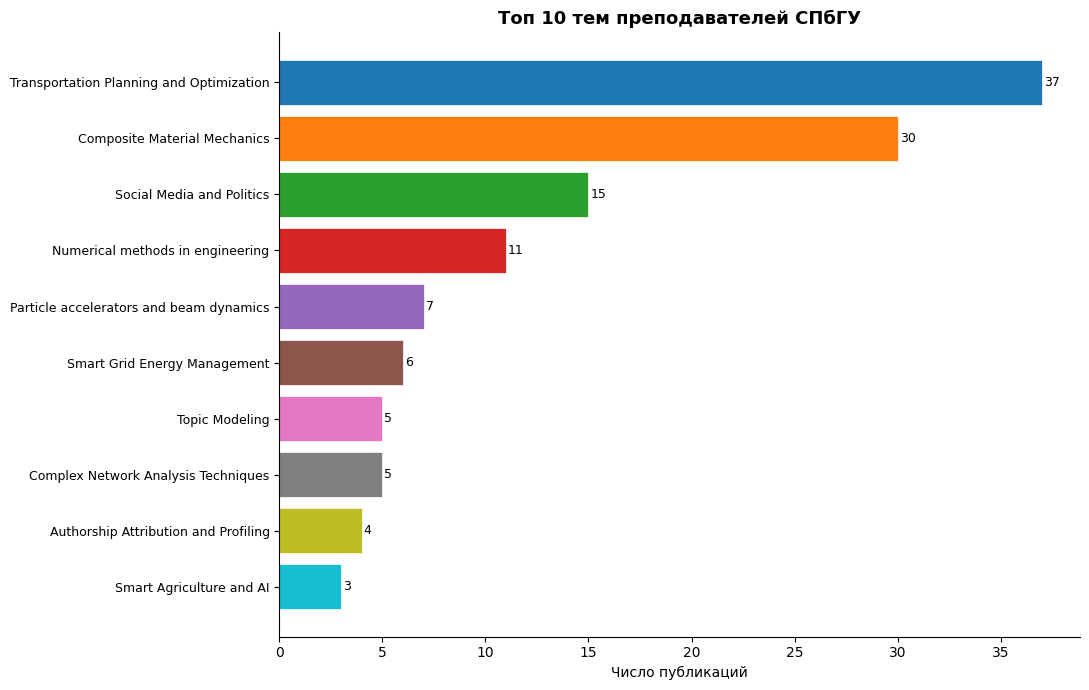

Сохранено: topics_openalex.png


In [5]:
df = (
    pd.concat(dfs_per_author.values(), ignore_index=True)
    .drop_duplicates(subset='id')
)

topic_counts = Counter(df['primary_topic.display_name'].dropna())

print('Топ 10 тем (все преподаватели):\n')
for topic, count in topic_counts.most_common(10):
    print(f'{count:3d} {topic}')

print()

print('Топ 3 темы по каждому преподавателю:')
for ma, df_author in dfs_per_author.items():
    last = ma.split()[-1]
    counts = Counter(df_author['primary_topic.display_name'].dropna())
    top3 = counts.most_common(3)
    print(f'\n  {ma}')
    for topic, count in top3:
        print(f'    {count:3d}  {topic}')

print()

top10 = topic_counts.most_common(10)
names = [t[0] for t in top10]
vals  = [t[1] for t in top10]

short = [' '.join(n.split()[:5]) + ('...' if len(n.split()) > 5 else '') for n in names]

fig, ax = plt.subplots(figsize=(11, 7))
colors = plt.cm.tab10(np.linspace(0, 0.9, len(top10)))
bars = ax.barh(range(len(top10)), vals[::-1], color=colors[::-1], edgecolor='white', linewidth=0.5)

ax.set_yticks(range(len(top10)))
ax.set_yticklabels(short[::-1], fontsize=9)
ax.set_xlabel('Число публикаций', fontsize=10)
ax.set_title(
    'Топ 10 тем преподавателей СПбГУ',
    fontsize=13, fontweight='bold'
)

for i, v in enumerate(vals[::-1]):
    ax.text(v + 0.1, i, str(v), va='center', fontsize=9)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('topics_openalex.png', dpi=150, bbox_inches='tight')
plt.show()
print('Сохранено: topics_openalex.png')